In [1]:
import tensorflow as tf
print("Versi TensorFlow:", tf.__version__)
print("Jumlah GPU yang Tersedia:", len(tf.config.experimental.list_physical_devices('GPU')))

2024-03-29 08:07:05.381963: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-29 08:07:05.382066: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-29 08:07:05.521259: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Versi TensorFlow: 2.15.0
Jumlah GPU yang Tersedia: 1


In [2]:
import tensorflow as tf
print("GPU Tersedia:", tf.test.is_gpu_available())

GPU Tersedia: True


In [3]:
import pandas as pd

# Membaca file CSV
data = pd.read_csv('/kaggle/input/fix-round3-plain-cipher-label-all-new-shuffled/FIX-round3-plain-cipher-label-all-new-shuffled.csv', dtype={'plaintext': str, 'ciphertext': str})

# Menampilkan jumlah data dengan label 0 dan 1
label_counts = data['label'].value_counts()
print("Jumlah data dengan label 0:", label_counts[0])
print("Jumlah data dengan label 1:", label_counts[1])

Jumlah data dengan label 0: 524291
Jumlah data dengan label 1: 524288


In [4]:
data['label'].unique()

array([0, 1])

In [5]:
# Menampilkan tipe data dari tiap kolom
print("\nTipe data tiap kolom:")
print(data.dtypes)


Tipe data tiap kolom:
plaintext     object
ciphertext    object
label          int64
dtype: object


In [6]:
data.tail(3)

,plaintext,ciphertext,label
1048576,01001111010011010100011100100000,01110101101111100101100100011110,1
1048577,01101000011101000111010001110000,01110010011101011101010000101110,0
1048578,00100000011100110111010001110101,01101111000101010010111010001100,1


In [7]:
from sklearn.preprocessing import OneHotEncoder

import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split

# Mengkonversi data result menjadi representasi numerik (one-hot encoding)
data['concated_features'] = data['plaintext'] + data['ciphertext'].astype(str)

X = []
for binary_string in data['concated_features']:
    one_hot_encoding = [int(bit) for bit in binary_string]
    X.append(one_hot_encoding)

X = np.array(X, dtype=np.int64)
Y = data['label']

In [8]:
# Menampilkan tipe data dari tiap kolom
print("\nTipe data tiap kolom:")
print(data.dtypes)


Tipe data tiap kolom:
plaintext            object
ciphertext           object
label                 int64
concated_features    object
dtype: object


In [9]:
data.head(3)

,plaintext,ciphertext,label,concated_features
0,00100000011010100110010101101110,11111100110000000110001000011010,0,0010000001101010011001010110111011111100110000...
1,00100000011011010110100101100011,00001100110100101100011100011000,1,0010000001101101011010010110001100001100110100...
2,00100000011100110110000101101000,11011000100101010111000101000011,0,0010000001110011011000010110100011011000100101...


In [10]:
print(X)

[[0 0 1 ... 0 1 0]
 [0 0 1 ... 0 0 0]
 [0 0 1 ... 0 1 1]
 ...
 [0 1 0 ... 1 1 0]
 [0 1 1 ... 1 1 0]
 [0 0 1 ... 1 0 0]]


In [11]:
print(Y)

0          0
1          1
2          0
3          0
4          0
          ..
1048574    1
1048575    1
1048576    1
1048577    0
1048578    1
Name: label, Length: 1048579, dtype: int64


In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Input, Model
from keras.layers import Input, Dense, Reshape, TimeDistributed
from keras.models import Sequential
from tensorflow.keras.layers import Input, Activation, Dense, LSTM, Attention
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score
import matplotlib.pyplot as plt

In [13]:
# Gunaka early-stopping untuk menentukan optimal epoch
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10, restore_best_weights=True)
    #tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=1)
]

In [14]:
input_shape = (64,1)  # Input shape for concated_features

# Definisikan input
inputs = Input(shape=input_shape)

In [15]:
# Definisikan fungsi attention
def bahdanau_attention(input_first_half, input_second_half):
    # Perhitungan skor perhatian menggunakan BahdanauAttention
    attention = layers.Attention()([input_first_half, input_second_half])
    # Kembalikan hasil perhatian
    return attention

In [16]:
lstm_model = Sequential()

# Layer LSTM pertama
# Layer LSTM pertama
lstm_output = LSTM(units=64, return_sequences=True)(inputs)

# Lapisan TimeDistributed untuk menerapkan lapisan Dense pada setiap waktu di dalam urutan
lstm_output = TimeDistributed(Dense(64))(lstm_output)

# Bagi input menjadi dua bagian terpisah menggunakan lapisan Lambda
split_input = layers.Lambda(lambda x: tf.split(x, num_or_size_splits=2, axis=-1))(lstm_output)
input_first_half, input_second_half = split_input

# Terapkan mekanisme perhatian
attention_output = bahdanau_attention(input_first_half, input_second_half)

# Flatten output dari LSTM
flatten_output = layers.Flatten()(attention_output)

# Output layer
output = Dense(1, activation='sigmoid')(flatten_output)

# Definisikan model
lstm_attention_model = Model(inputs=inputs, outputs=output)

# Compile model
lstm_attention_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print summary of the model
lstm_attention_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64, 64)    │     16,896 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 64, 64)    │      4,160 │ lstm[0][0]        │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ [(None, 64, 32),  │          0 │ time_distributed… │
│                     │ (None, 64, 32)]   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 64, 32)    │          0 │ lambda[0][0],     │
│ (Attention)         │                   │            │ lambda[0][1]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2048)      │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      2,049 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,105 (90.25 KB)

 Trainable params: 23,105 (90.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Training, validasi, dan tes
from sklearn.model_selection import train_test_split

# Memisahkan data menjadi training (60%), validasi (20%), dan test (20%)
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# Output informasi ukuran dataset
print("Ukuran dataset pelatihan (X_train):", X_train.shape)
print("Ukuran dataset validasi (X_val):", X_val.shape)
print("Ukuran dataset pengujian (X_test):", X_test.shape)

Ukuran dataset pelatihan (X_train): (838863, 64)
Ukuran dataset validasi (X_val): (104858, 64)
Ukuran dataset pengujian (X_test): (104858, 64)


In [18]:
lstm_attention_history = lstm_attention_model.fit(X_train, Y_train, epochs=100, batch_size=100, callbacks=my_callbacks, validation_data=(X_val, Y_val))

Epoch 1/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 82s 9ms/step - accuracy: 0.5003 - loss: 0.6933 - val_accuracy: 0.4979 - val_loss: 0.6932
Epoch 2/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 77s 9ms/step - accuracy: 0.5009 - loss: 0.6932 - val_accuracy: 0.4979 - val_loss: 0.6932
Epoch 3/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 75s 9ms/step - accuracy: 0.5008 - loss: 0.6932 - val_accuracy: 0.5064 - val_loss: 0.6931
Epoch 4/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 75s 9ms/step - accuracy: 0.5007 - loss: 0.6932 - val_accuracy: 0.4979 - val_loss: 0.6932
Epoch 5/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 74s 9ms/step - accuracy: 0.4997 - loss: 0.6932 - val_accuracy: 0.4980 - val_loss: 0.6932
Epoch 6/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 74s 9ms/step - accuracy: 0.5013 - loss: 0.6932 - val_accuracy: 0.5021 - val_loss: 0.6931
Epoch 7/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 74s 9ms/step - accuracy: 0.5018 - loss: 0.6931 - val_accuracy: 0.5340 - val_loss: 0.6899
Epoch 8/100
8389/8389 ━━━━━━━━━━━━━━━━━━━━ 74s 9ms/step - accuracy: 0.5359 -

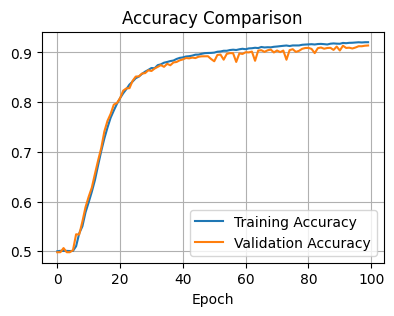

In [19]:
plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.plot(lstm_attention_history.history['accuracy'], label='Training Accuracy')
plt.plot(lstm_attention_history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.grid()

In [20]:
lstm_attention_test_loss, lstm_attention_test_accuracy = lstm_attention_model.evaluate(X_test, Y_test)

3277/3277 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9155 - loss: 0.2274


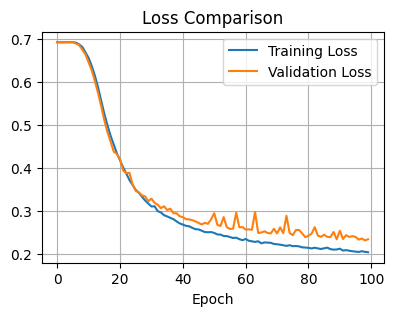

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.plot(lstm_attention_history.history['loss'], label='Training Loss')
plt.plot(lstm_attention_history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.grid()
plt.show()

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import seaborn as sns

# Predict labels for test set
Y_pred = lstm_attention_model.predict(X_test)
Y_pred_classes = np.round(Y_pred)

# Calculate confusion matrix
conf_matrix = confusion_matrix(Y_test, Y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(Y_test, Y_pred_classes)
precision = precision_score(Y_test, Y_pred_classes)
recall = recall_score(Y_test, Y_pred_classes)

3277/3277 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step


In [23]:
print("Confusion Matrix:")
print(conf_matrix)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Confusion Matrix:
[[48076  4540]
 [ 4404 47838]]
Accuracy: 0.9147036945202083
Precision: 0.9133223872618275
Recall: 0.915700011485012


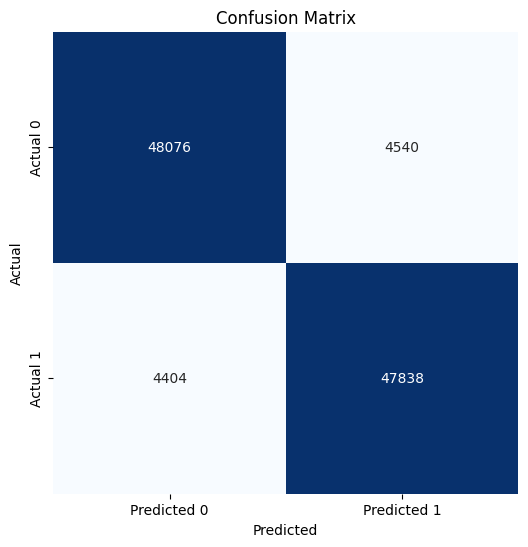

In [24]:
# Plot confusion matrix
plt.figure(figsize=(6, 6))
plt.title('Confusion Matrix')
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g', cbar=False, 
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

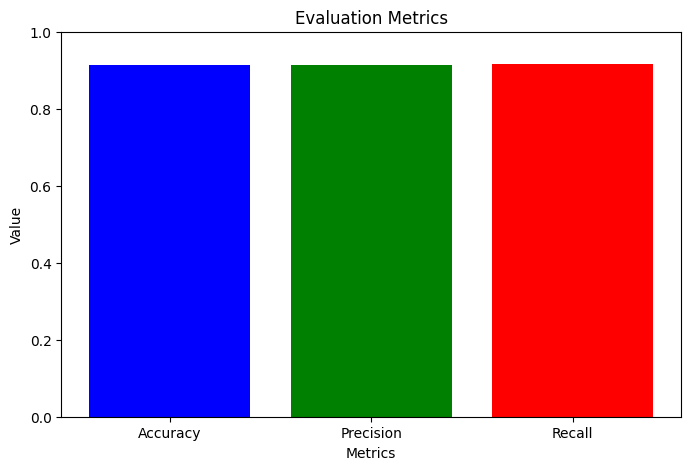

In [25]:
# Plot evaluation metrics
metrics = ['Accuracy', 'Precision', 'Recall']
values = [accuracy, precision, recall]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'green', 'red'])
plt.title('Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Value')
plt.ylim(0, 1)
plt.show()